# Assignment 1: From Dirty Data to Predictive Models
**Dataset:** UCI Heart Disease (76-attribute raw files)

## 1. Introduction
This notebook demonstrates an end-to-end ML workflow to predict heart disease presence. We clean 'dirty' clinical data, engineer features, and compare Generative (Naive Bayes) vs. Discriminative (Linear Regression) models.

## 2. Setup and Data Loading
We load the UCI dataset. Missing values are documented as '-9' in the raw text.

In [2]:
import pandas as pd
import numpy as np
import re
import urllib.request as request
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score

# Data Set Files (4)
urls = {
    "switzerland.data": "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/switzerland.data",
    "cleveland.data": "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/cleveland.data",
    "hungarian.data": "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/hungarian.data",
    "long-beach-va.data": "https://raw.githubusercontent.com/Daniel-Manjarrez/AppliedMachineLearningAssignment1/main/long-beach-va.data"
}
for filename, url in urls.items():
    request.urlretrieve(url, filename)

# Clean a string token to extract a numeric value by doing the following:
# - Remove all characters except digits, minus sign, and dot
# - Convert special missing values ('-9', '-9.0', '') specifed in dataset README to np.nan
# - Attempt to convert the cleaned string to float
def sanitize_token(token):
    token = re.sub(r'[^\d\.\-]', '', token.strip())
    if token in ('', '-9', '-9.0'):
        return np.nan
    try:
        return float(token)
    except:
        return np.nan

def load_heart_data_raw(file):
    # 14 standard indices as per documentation (0-indexed from the 76-attribute total list)
    # age(#3), sex(#4), cp(#9), trestbps(#10), chol(#12), fbs(#16), restecg(#19),
    # thalach(#32), exang(#38), oldpeak(#40), slope(#41), ca(#44), thal(#51), num(#58)
    indices = [2, 3, 8, 9, 11, 15, 18, 31, 37, 39, 40, 43, 50, 57]
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
               'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

    # Read the raw data file line by line, split each line into tokens by
    # whitespace or commas, remove any empty tokens, and collect all tokens
    # into a single flat list for further processing.
    with open(file, 'r', encoding='latin1') as f:
        all_tokens = [p for line in f for p in re.split(r'\s+|,', line.strip()) if p]

    # Group tokens into 76-attribute records to then extract the 14 relevant fields
    rows = [[sanitize_token(chunk[idx]) for idx in indices] for i in range(0, len(all_tokens), 76) if i + 76 <= len(all_tokens) for chunk in [all_tokens[i : i+76]]]

    return pd.DataFrame(rows, columns=columns)

# Load Files of the Data Set into Data Frames List
dfs = []
for f in urls.keys():
    try:
        df_part = load_heart_data_raw(f)
        dfs.append(df_part)
        print(f"Loaded {f}: {len(df_part)} records")
    except FileNotFoundError:
        print(f"Warning: {f} not found")

# Combine the Data Frames
df_combined = pd.concat(dfs, ignore_index=True)
print(f"Total dataset shape: {df_combined.shape}")

Loaded switzerland.data: 123 records
Loaded cleveland.data: 297 records
Loaded hungarian.data: 294 records
Loaded long-beach-va.data: 200 records
Total dataset shape: (914, 14)


## 3. Data Cleaning and Splitting Data
We binarize the target first in order to convert target into a binary classification problem. Crucially, we split the data **before** imputation to avoid data leakage.

In [3]:
# 1. Binarize diagnosis num as new target column
df_combined['target'] = (df_combined['num'] > 0).astype(int)
X = df_combined.drop(['num', 'target'], axis=1)
y = df_combined['target']

# 2. Define column types
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 3. Train/Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Binarization and Splitting Complete")

Binarization and Splitting Complete


## 4. Feature Engineering
We use a `ColumnTransformer` to handle numeric and categorical pipelines separately. Numeric columns use MICE (`IterativeImputer`), while categorical columns use Mode imputation (`SimpleImputer(strategy='most_frequent')`). We use Standard Scaling for numerical features to ensure a fair comparison for the Linear model. This pipeline setup ensures imputation is fitted only on the training set.

In [4]:
# Normalization via Scaling and MICE Imputation on Numerical Features
numeric_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42)),
    ('scaler', StandardScaler())
])

# Categoical Encoding via One-Hot Encoding and Mode Imputation
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Using ColumnTransformer to Apply Our Feature Engineering
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Fit on Training Data and Transform Both Train and Test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Processed features: {X_train_processed.shape[1]}")

Processed features: 58


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 5. Model Training
### 5.1 Naive Bayes (Generative)
We compare $\alpha=1.0$ and $\alpha=0.01$ to observe the effects of Laplace smoothing as well as its absence with $\alpha=0$.

In [5]:
# Naive Bayes

# NB with Alpha 1.0
nb_1 = BernoulliNB(alpha=1.0).fit(X_train_processed, y_train)
y_pred_nb1 = nb_1.predict(X_test_processed)
# NB with Alpha 0.01
nb_01 = BernoulliNB(alpha=0.01).fit(X_train_processed, y_train)
y_pred_nb01 = nb_01.predict(X_test_processed)
# NB with Alpha 0
nb_0 = BernoulliNB(alpha=0).fit(X_train_processed, y_train)
y_pred_nb0 = nb_0.predict(X_test_processed)

print(f"NB (alpha=1.0) Accuracy: {accuracy_score(y_test, y_pred_nb1):.4f}")
print(f"NB (alpha=0.01) Accuracy: {accuracy_score(y_test, y_pred_nb01):.4f}")
print(f"NB (alpha=0) Accuracy: {accuracy_score(y_test, y_pred_nb0):.4f}")

NB (alpha=1.0) Accuracy: 0.7541
NB (alpha=0.01) Accuracy: 0.7541
NB (alpha=0) Accuracy: 0.4481


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:1209: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Smoothing Comparison Explanation
Laplace smoothing (alpha) prevents zero-probability errors for features not seen in the training set. A higher alpha (1.0) provides stronger regularization, making the model more robust to noise but potentially less accurate if the training sample is small. A lower alpha (0.01) allows the model to fit the training data more closely, but potentially increases the risk of overfitting.

### 5.2 Linear Regression (Discriminative)
Applied to binary classification using a 0.5 probability threshold for classification and explored L1/L2 regularization.

In [6]:
# Linear Regression (0.5 threshold)
# Base Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = (lr.predict(X_test_processed) >= 0.5).astype(int)

# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)
y_pred_ridge = (ridge.predict(X_test_processed) >= 0.5).astype(int)

# Lasso Regression (L1)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_processed, y_train)
y_pred_lasso = (lasso.predict(X_test_processed) >= 0.5).astype(int)

print(f"Linear Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Ridge (L2) Accuracy: {accuracy_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso (L1) Accuracy: {accuracy_score(y_test, y_pred_lasso):.4f}")

Linear Regression Accuracy: 0.7650
Ridge (L2) Accuracy: 0.7760
Lasso (L1) Accuracy: 0.7596


## 6. Evaluation and Comparison
Visualizing performance using Confusion Matrices and the ROC Curve.

Naive Bayes (alpha=1.0) -> Precision: 0.786, Recall: 0.762, F1-score: 0.774
Linear Regression -> Precision: 0.784, Recall: 0.792, F1-score: 0.788


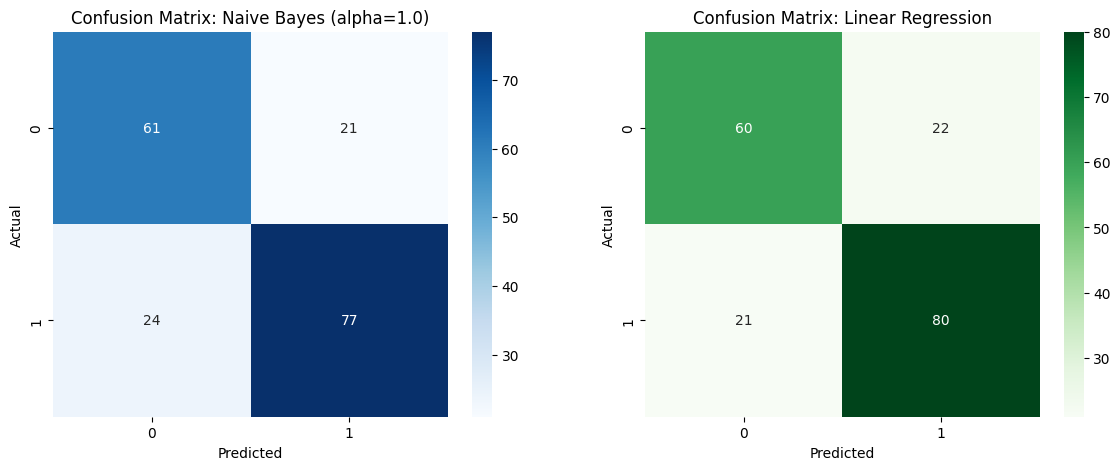

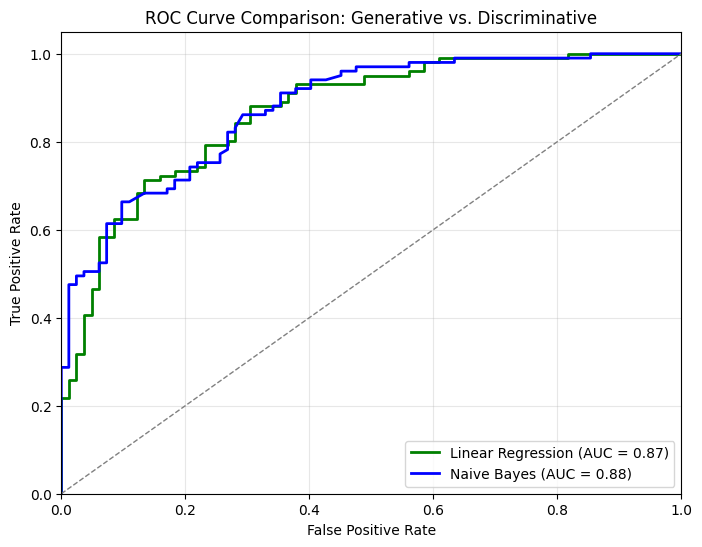

Naive Bayes -> AUC: 0.876
Linear Regression -> AUC: 0.868


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix: Naive Bayes
sns.heatmap(confusion_matrix(y_test, y_pred_nb1), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Naive Bayes (alpha=1.0)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Compute Precision, Recall, F1 for NB
precision_nb = precision_score(y_test, y_pred_nb1)
recall_nb = recall_score(y_test, y_pred_nb1)
f1_nb = f1_score(y_test, y_pred_nb1)
print(f"Naive Bayes (alpha=1.0) -> Precision: {precision_nb:.3f}, Recall: {recall_nb:.3f}, F1-score: {f1_nb:.3f}")

# Confusion Matrix: Linear Regression
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: Linear Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Compute Precision, Recall, F1 for LR
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"Linear Regression -> Precision: {precision_lr:.3f}, Recall: {recall_lr:.3f}, F1-score: {f1_lr:.3f}")

plt.show()
plt.figure(figsize=(8, 6))

# ROC Curve for Linear Regression
y_scores_lr = lr.predict(X_test_processed) # Continuous output serves as scores
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_scores_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Linear Regression (AUC = {roc_auc_lr:.2f})')

# ROC Curve for Naive Bayes ROC
y_probs_nb = nb_1.predict_proba(X_test_processed)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

# Plot
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Luck line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Generative vs. Discriminative')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Print metrics
print(f"Naive Bayes -> AUC: {roc_auc_nb:.3f}")
print(f"Linear Regression -> AUC: {roc_auc_lr:.3f}")